In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sanyamdhadiwal2302/netflix-data")

print("Path to dataset files:", path)

100%|█████████████████████████████████████████████████████████████████████████████| 1.70M/1.70M [00:00<00:00, 2.00MB/s]

Extracting files...


Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\sanyamdhadiwal2302\netflix-data\versions\1


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Initial data inspection

In [2]:
df = pd.read_csv(r"C:\Users\USER\.cache\kagglehub\datasets\sanyamdhadiwal2302\netflix-data\versions\1\mymoviedb.csv", engine="python")
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [3]:
df.tail()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
9832,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...
9833,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9834,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9835,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...
9836,1984-09-23,Threads,Documentary style account of a nuclear holocau...,13.354,186,7.8,en,"War, Drama, Science Fiction",https://image.tmdb.org/t/p/original/lBhU4U9Eeh...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [5]:
df.isna().sum()

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["Title"].value_counts()[df["Title"].value_counts() > 1]

Title
Beauty and the Beast          4
Alice in Wonderland           4
The Little Mermaid            3
Awake                         3
Halloween                     3
                             ..
Doctor Strange                2
Down                          2
Bad Boys                      2
Life                          2
The Last House on the Left    2
Name: count, Length: 288, dtype: int64

In [8]:
df[df.duplicated(subset=["Title", "Release_Date"], keep=False)]

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url


In [9]:
# convert data types
cols = ["Vote_Count", "Vote_Average"]
df[cols] = df[cols].apply(pd.to_numeric,  errors="coerce")

In [10]:
df["Vote_Count"] = pd.to_numeric(df["Vote_Count"])

In [11]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9826.000000,9826.000000
mean,40.320570,1392.943721,6.439467
std,108.874308,2611.303856,1.129797
min,7.100000,0.000000,0.000000
25%,16.127500,146.000000,5.900000
50%,21.191000,444.000000,6.500000
75%,35.174500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [12]:
#Checking the missing values
df[df.isna().any(axis=1)]

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
1105,2013-10-20,Pixie Hollow Bake Off,Tink challenges Gelata to see who can bake the...,NaN,NaN,NaN,None,None,None
1106,- Just Desserts,None,None,NaN,NaN,NaN,None,None,None
1107,- If The Hue Fits,None,None,NaN,NaN,NaN,None,None,None
1108,- Dust Up,None,None,NaN,NaN,NaN,None,None,None
1109,- Scents And Sensibility,None,None,NaN,NaN,NaN,None,None,None
1110,- Just One Of The Girls,None,None,NaN,NaN,NaN,None,None,None
1111,- Volleybug,None,None,NaN,NaN,NaN,None,None,None
1112,- Hide And Tink,None,None,NaN,NaN,NaN,None,None,None
1113,- Rainbow's Ends,None,None,NaN,NaN,NaN,None,None,None
1114,- Fawn And Games,None,None,NaN,NaN,NaN,None,None,None


In [13]:
#drop missing values
df = df.dropna()

# Exploratory Data Analysis

## Movie Distribution by Release Date

In [14]:
df["Release_Date"]=pd.to_datetime(df["Release_Date"])
df["Year"] = df["Release_Date"].dt.year
df["Month"]=df["Release_Date"].dt.month
df["Day"]=df["Release_Date"].dt.day

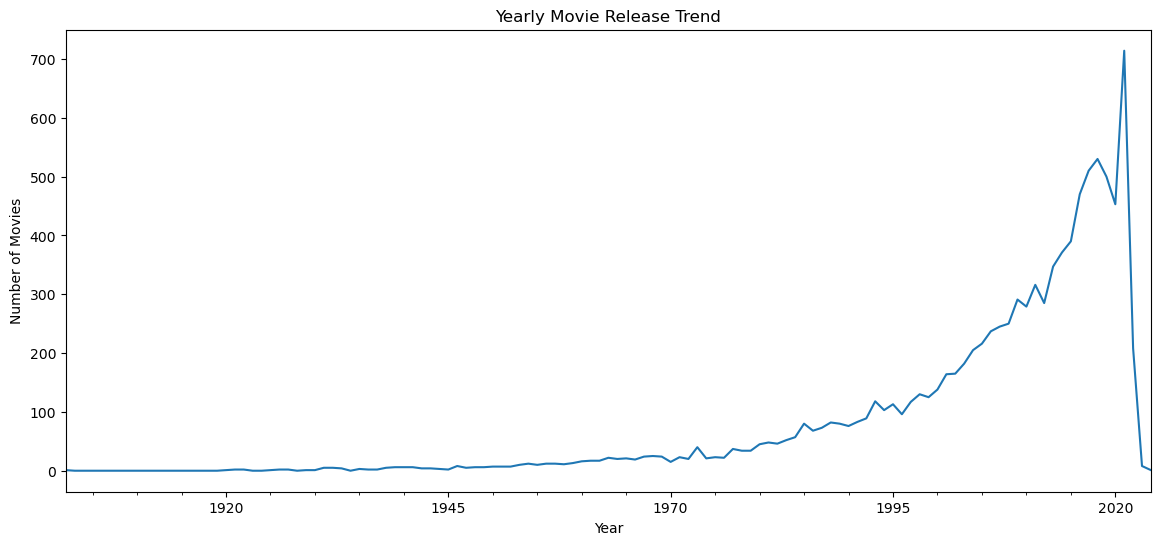

In [15]:
df = df.set_index("Release_Date", drop=False)

yearly = df.resample("YE").size()

yearly.plot(figsize=(14,6))
plt.title("Yearly Movie Release Trend")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()


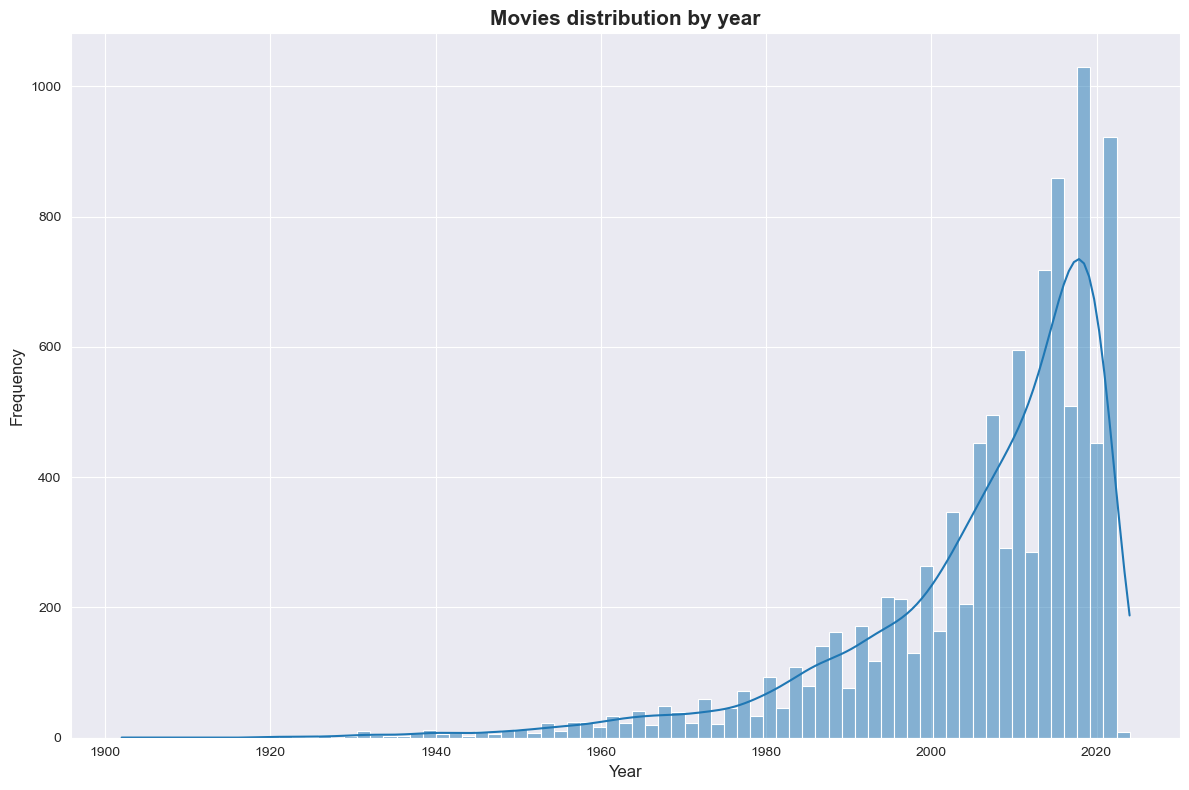

In [16]:
plt.figure(figsize=(12,8))
sns.set_style("darkgrid")
sns.histplot( data=df , x="Year", bins="fd", kde=True)
plt.title("Movies distribution by year", fontsize=15 , weight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()


In [113]:
df["Year"].describe()

count    9826.000000
mean     2006.202931
std        15.686202
min      1902.000000
25%      2000.000000
50%      2011.000000
75%      2017.000000
max      2024.000000
Name: Year, dtype: float64

The dataset spans movie releases from the early 1900s to 2020. Movie production is very low in the early decades and increases sharply toward the 2000–2020 period, where most films are concentrated. 

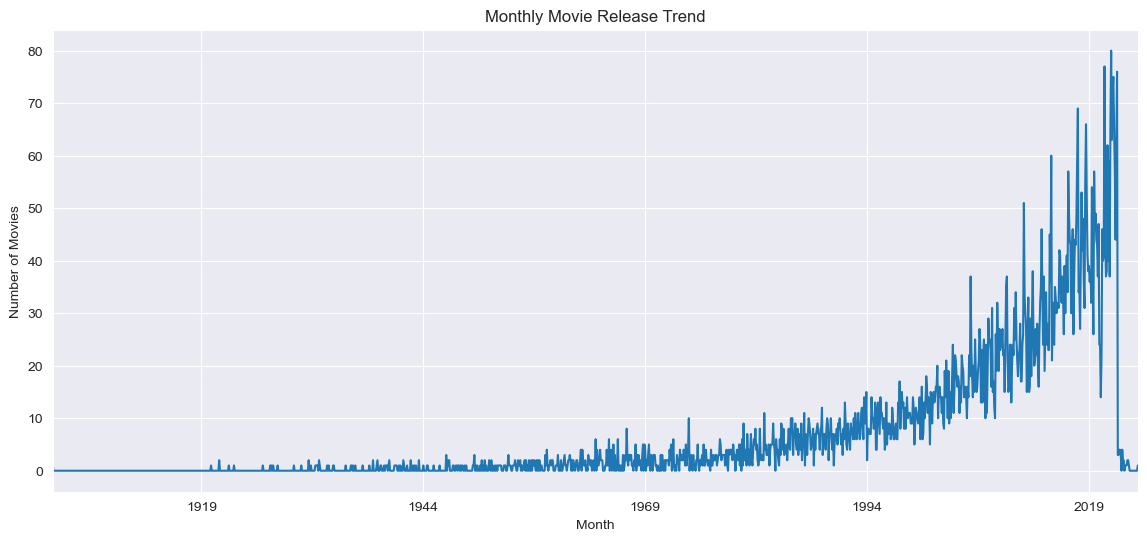

In [17]:
df = df.set_index("Release_Date", drop=False)

monthly = df.resample("ME").size()

monthly.plot(figsize=(14,6))
plt.title("Monthly Movie Release Trend")
plt.xlabel("Month")
plt.ylabel("Number of Movies")
plt.show()

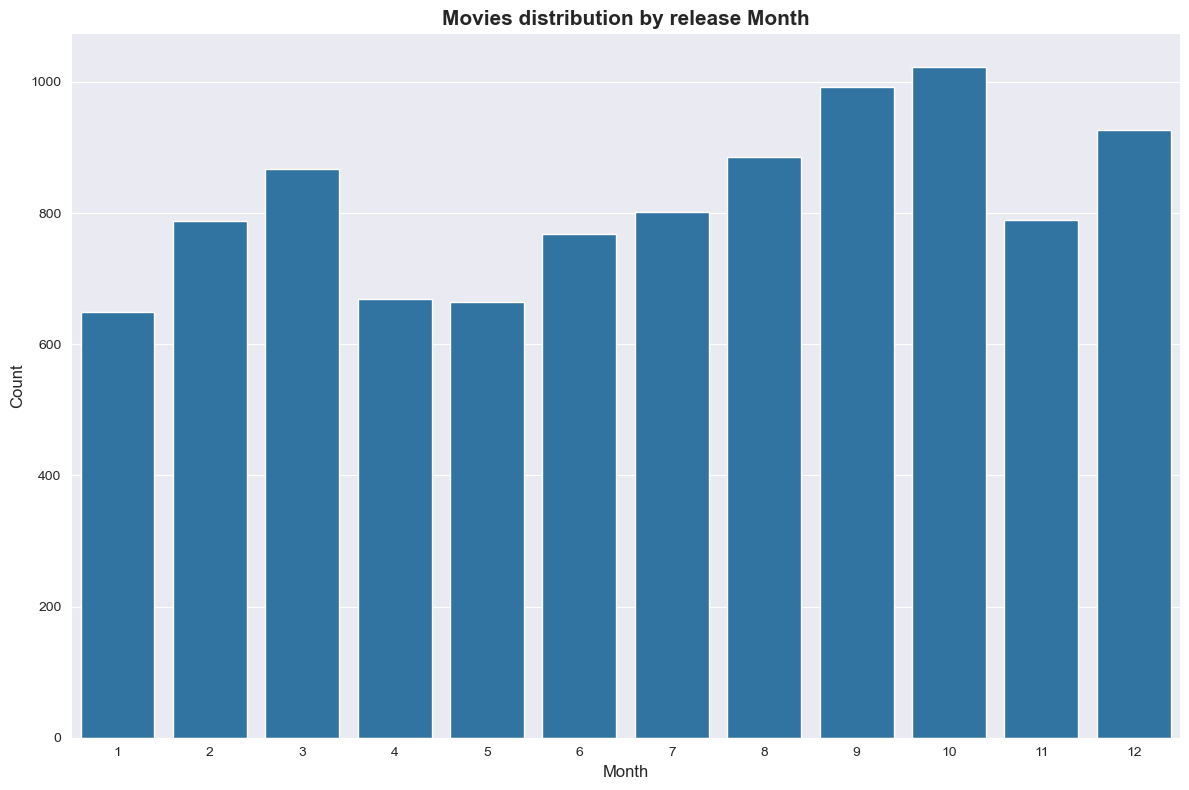

In [18]:
count = df.groupby("Month").size().reset_index(name="Count")
plt.figure(figsize=(12,8))
sns.set_style("darkgrid")
sns.barplot(data = count , x="Month" , y="Count")
plt.title("Movies distribution by release Month", fontsize=15 , weight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

October and September show the highest number of movie releases in the dataset. However, there is no clear or consistent month‑to‑month trend. In some parts of the year the number of releases increases from one month to the next, in others it remains relatively stable, and in some months it decreases. Overall, the distribution does not follow a smooth seasonal pattern, indicating that movie releases are spread irregularly across the calendar year.

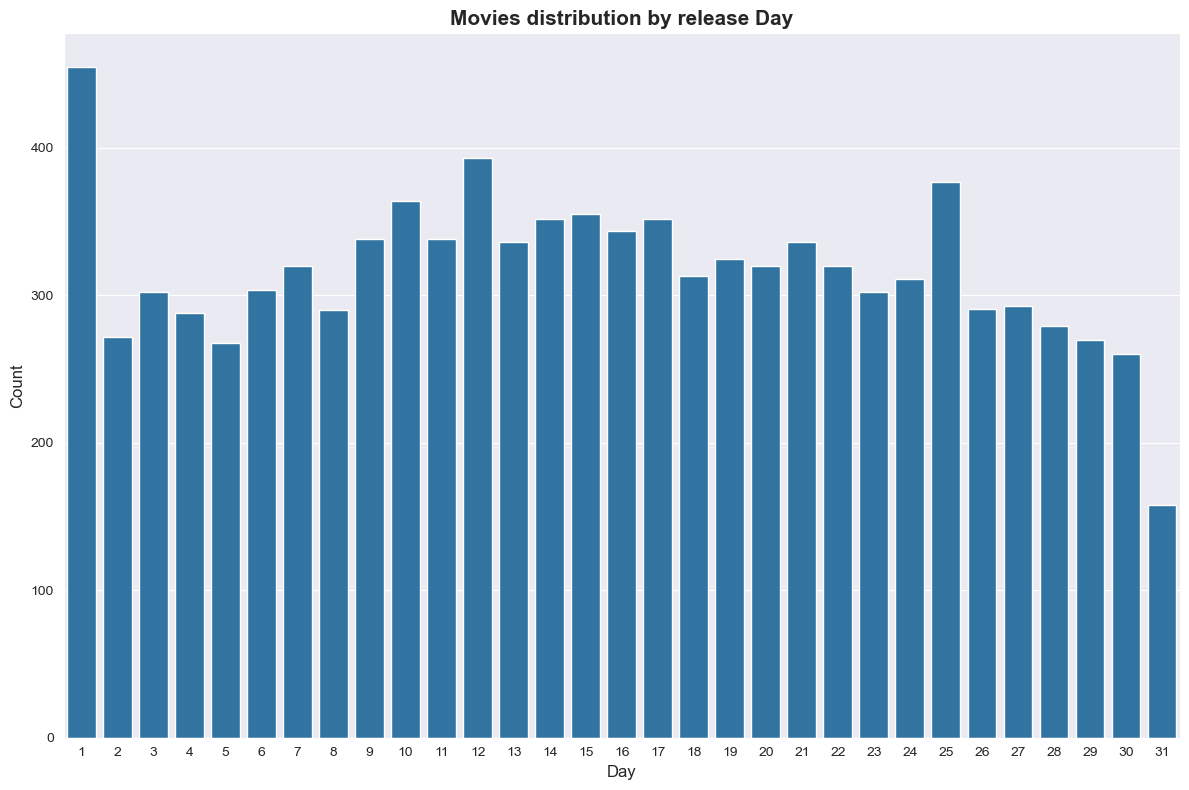

In [19]:
count = df.groupby("Day").size().reset_index(name="Count")
plt.figure(figsize=(12,8))
sns.set_style("darkgrid")
sns.barplot(data = count , x="Day" , y="Count")
plt.title("Movies distribution by release Day", fontsize=15 , weight="bold")
plt.xlabel("Day", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

There is no clear pattern in the distribution of movie release days. Apart from the first day of the month, which shows a noticeably higher number of releases, the remaining days exhibit relatively similar frequencies. This suggests that, aside from a preference for releasing movies on the 1st, all other days of the month have roughly the same likelihood of being used as release dates, with no consistent upward or downward trend across the month.

## Popularity distribution

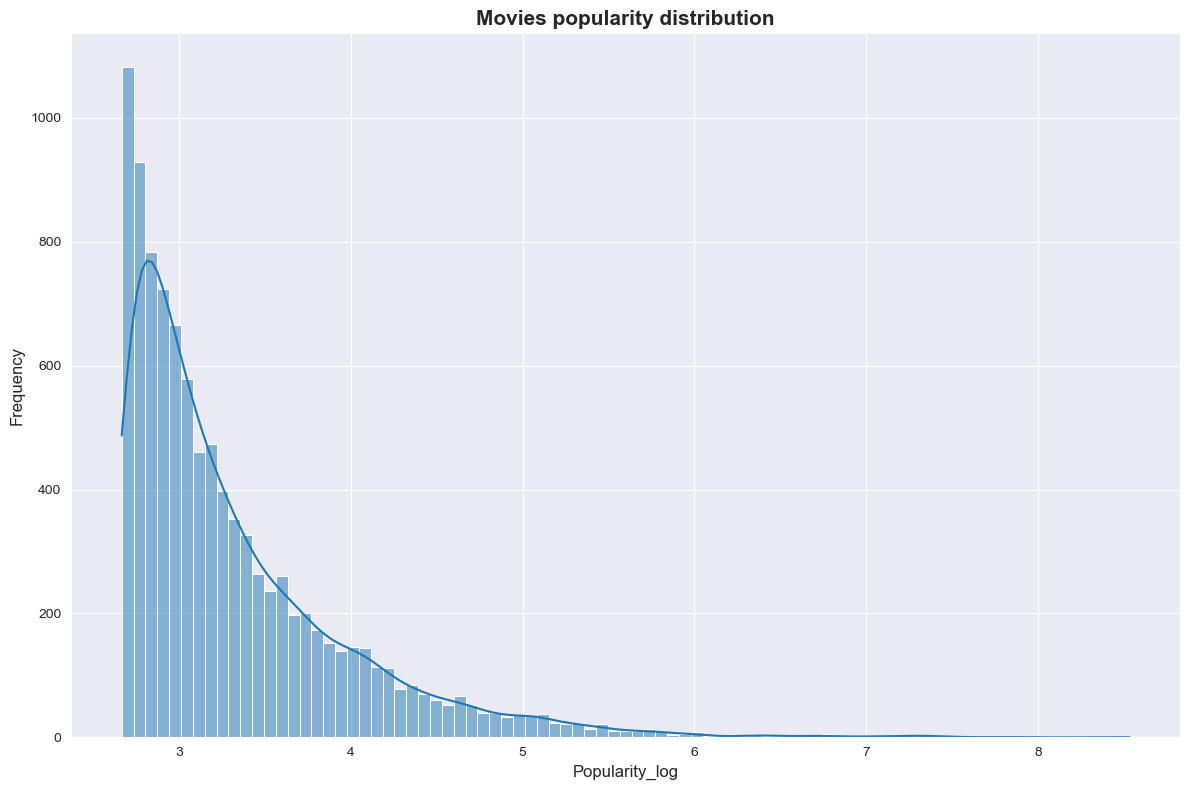

In [20]:
df["Popularity_log"]=np.log1p(df["Popularity"])
plt.figure(figsize=(12,8))
sns.set_style("darkgrid")
sns.histplot( data=df , x="Popularity_log", bins="fd", kde=True)
plt.title("Movies popularity distribution", fontsize=15 , weight="bold")
plt.xlabel("Popularity_log", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()

Most movies have low popularity values, while only a small number achieve very high popularity. This creates a right‑skewed distribution, where the majority of observations cluster at the lower end and the tail extends toward higher popularity scores.

## Vote Count Distribution

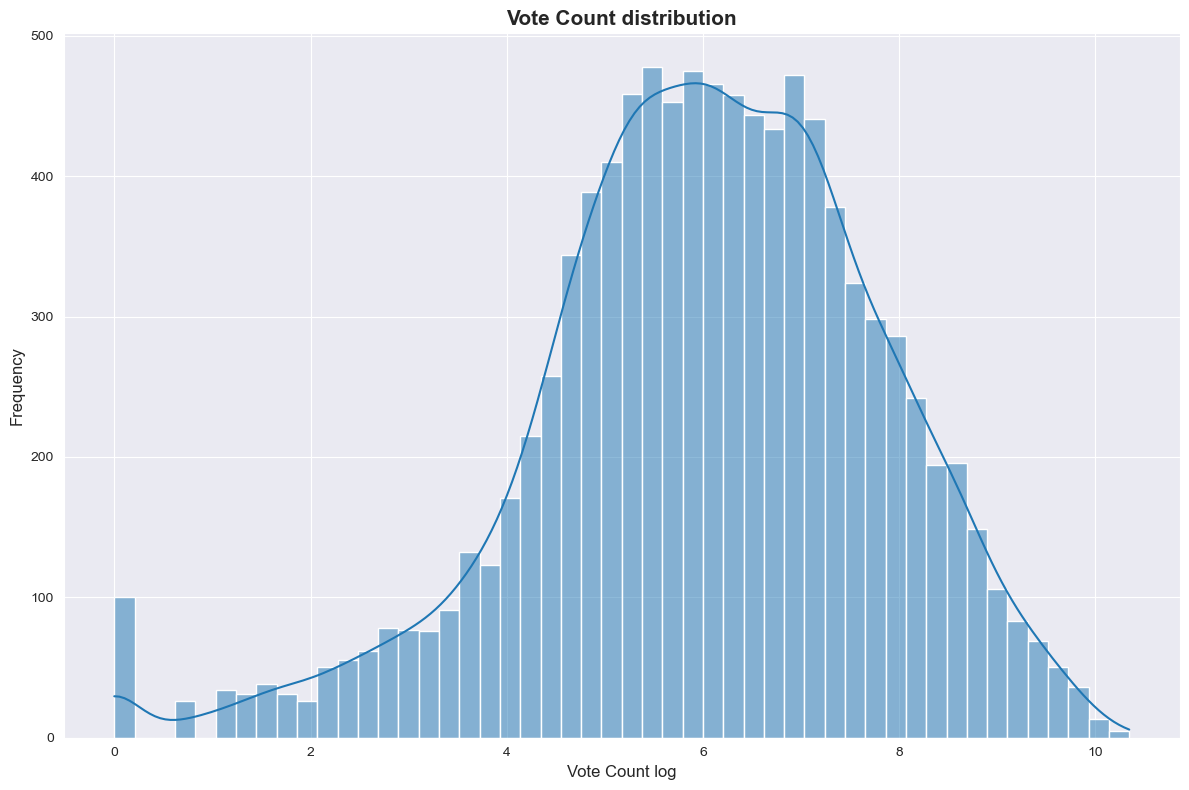

In [21]:
df["Vote_Count_log"]=np.log1p(df["Vote_Count"])
plt.figure(figsize=(12,8))
sns.set_style("darkgrid")
sns.histplot( data=df , x="Vote_Count_log", bins="fd", kde=True)
plt.title("Vote Count distribution", fontsize=15 , weight="bold")
plt.xlabel("Vote Count log", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
df["Vote_Count_log"].skew()

np.float64(-0.5873728991568369)

After applying a logarithmic transformation, the vote count distribution becomes more balanced but shows a slight left skew (skewness = –0.59). This indicates that a small number of movies have very low vote counts, while most movies cluster around moderate values.

## Vote Average Distribution

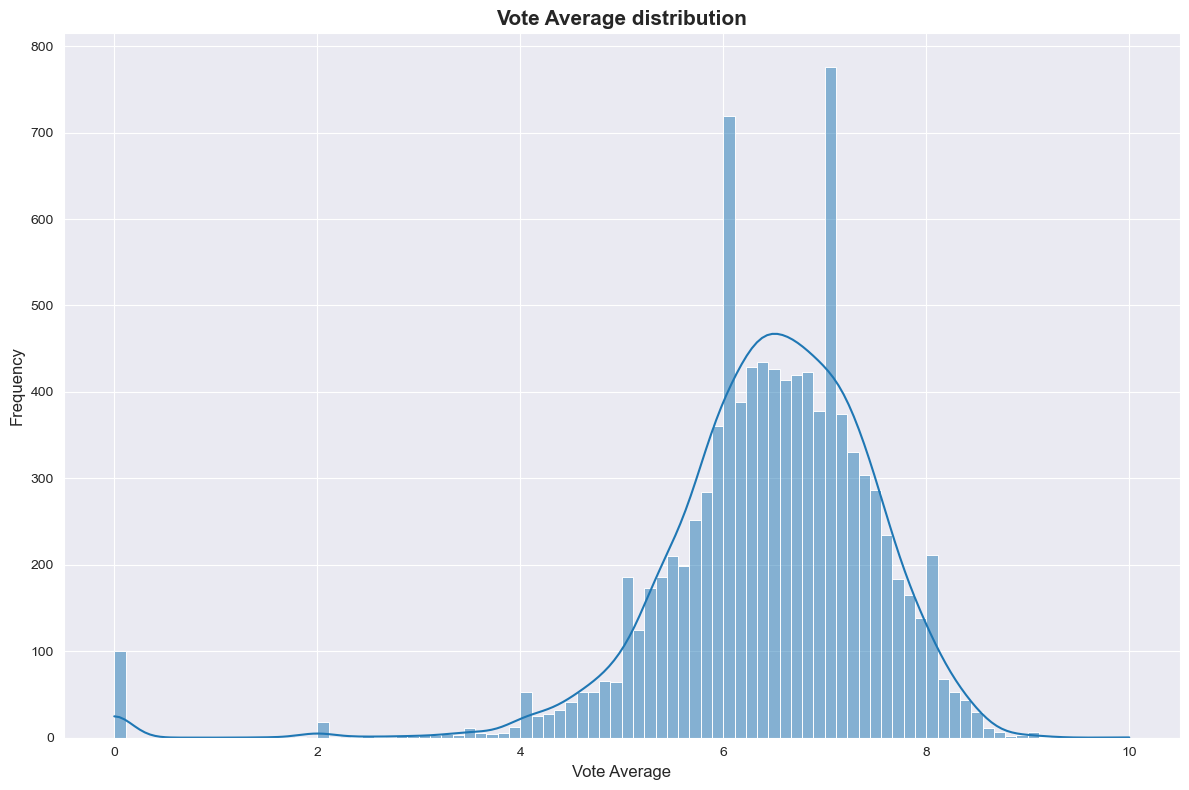

In [23]:
plt.figure(figsize=(12,8))
sns.set_style("darkgrid")
sns.histplot( data=df , x="Vote_Average", bins="fd", kde=True)
plt.title("Vote Average distribution", fontsize=15 , weight="bold")
plt.xlabel("Vote Average", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()


The distribution is slightly left‑skewed, meaning the tail extends toward the lower vote‑average values. Most movies cluster around mid‑to‑high ratings, especially between 6 and 7, which appear to be the most common scores. Only a smaller number of movies receive very low ratings.

## Language Distribution

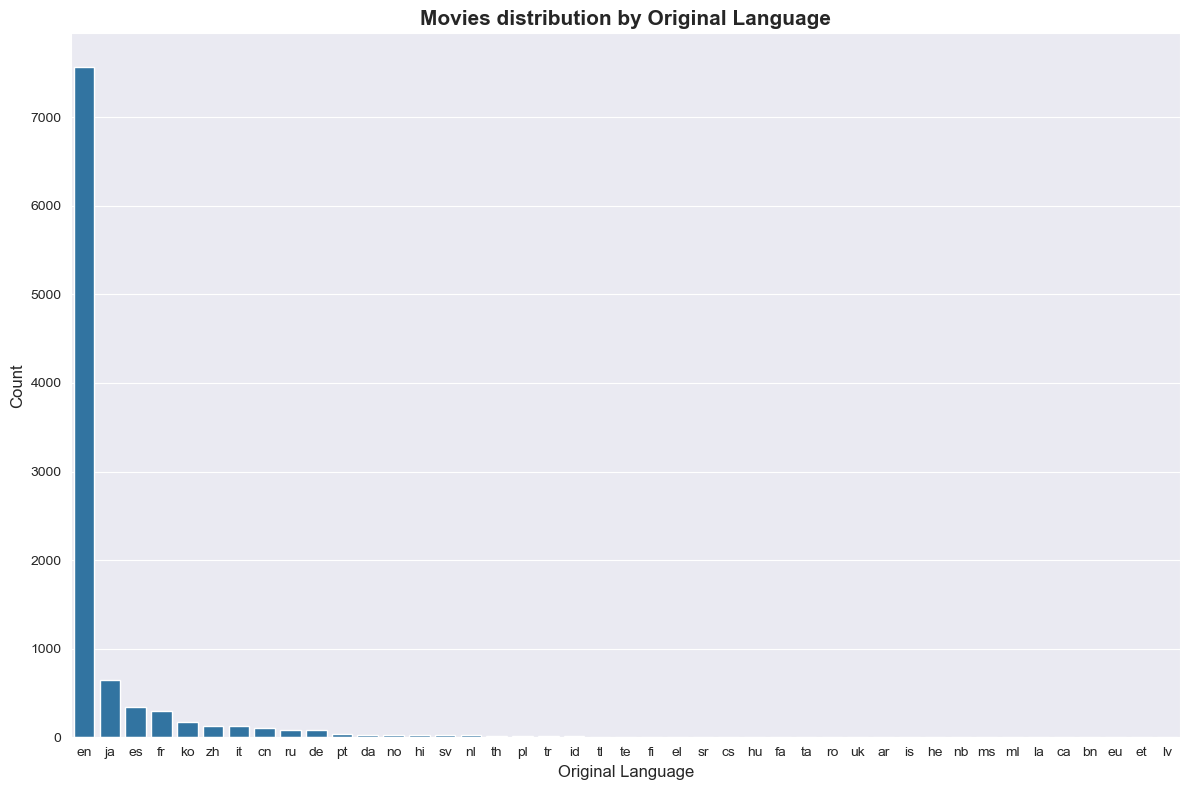

In [24]:
count = df.groupby("Original_Language").size().reset_index(name="Count")
count = count.sort_values("Count", ascending=False)
plt.figure(figsize=(12,8))
sns.set_style("darkgrid")
sns.barplot(data = count , x="Original_Language" , y="Count")
plt.title("Movies distribution by Original Language", fontsize=15 , weight="bold")
plt.xlabel("Original Language", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

In [25]:
count = df.groupby("Original_Language").size().reset_index(name="Count")
count["Percentage"] = round((count["Count"] / count["Count"].sum()) * 100, 2)
count = count.sort_values("Count", ascending=False)

count.head()

,Original_Language,Count,Percentage
8,en,7569,77.03
21,ja,645,6.56
9,es,339,3.45
14,fr,292,2.97
22,ko,170,1.73


English dominates the dataset, accounting for about 77% of all movies. Japanese follows with around 6.5%, while Spanish, French, and Korean each contribute only a small share (between 1–3.5%). This shows that the dataset is heavily skewed toward English‑language productions, with all other languages representing relatively small proportions.

## Genre Dsitribution

In [26]:
Genre_list = df["Genre"].to_list()

all_genres = []

for g in Genre_list:
    parts = g.split(",")   # split by comma
    parts = [p.strip() for p in parts]  # remove spaces
    all_genres.extend(parts)

unique_genres = set(all_genres)

unique_genres

{'Action',
 'Adventure',
 'Animation',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Family',
 'Fantasy',
 'History',
 'Horror',
 'Music',
 'Mystery',
 'Romance',
 'Science Fiction',
 'TV Movie',
 'Thriller',
 'War',
 'Western'}

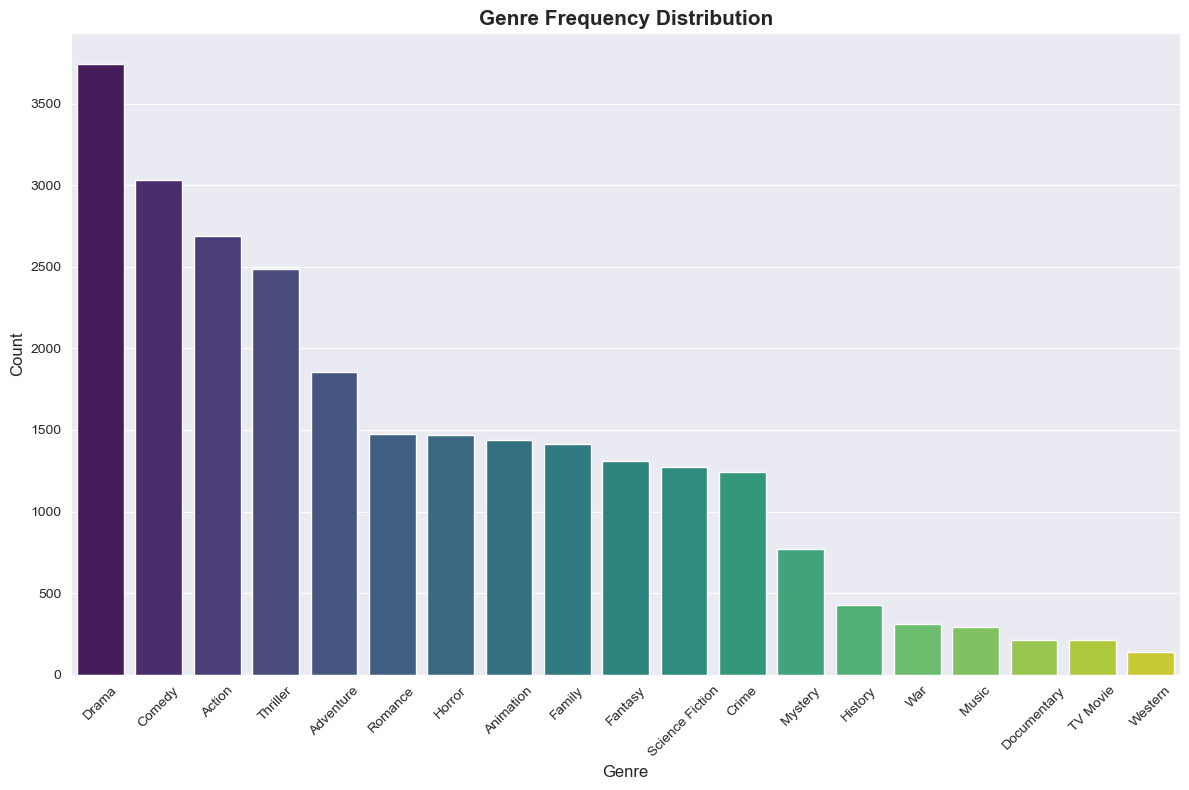

In [27]:
from collections import Counter

genre_counts = Counter(all_genres)

genre_df = pd.DataFrame(genre_counts.items(), columns=["Genre", "Count"])
genre_df = genre_df.sort_values("Count", ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(data=genre_df, x="Genre", y="Count", hue="Genre", palette="viridis", legend=False)
plt.title("Genre Frequency Distribution", fontsize=15, weight="bold")
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
genre_df["Percentage"] = round((genre_df["Count"] / genre_df["Count"].sum()) * 100, 2)
genre_df = genre_df.sort_values("Count", ascending=False).reset_index(drop=True)
genre_df

,Genre,Count,Percentage
0,Drama,3744,14.52
1,Comedy,3031,11.75
2,Action,2686,10.41
3,Thriller,2488,9.65
4,Adventure,1853,7.18
5,Romance,1476,5.72
6,Horror,1470,5.70
7,Animation,1438,5.58
8,Family,1414,5.48
9,Fantasy,1308,5.07


Drama is the most common genre, appearing in about 14.5% of all genre tags. Comedy follows with 11.75%, then Action with 10.41%, Thriller with 9.65%, and Adventure with 7.18%. This shows that the dataset is dominated by story‑driven genres (Drama, Comedy, Action), while more niche genres appear less frequently.

In [29]:
from itertools import combinations


df['genre_lists'] = df['Genre'].str.split(',')

pair_counter = Counter()

for genres in df['genre_lists']:
    # Only count pairs if there are 2+ genres
    if len(genres) > 1:
        pairs = combinations(sorted(genres), 2)
        pair_counter.update(pairs)

all_genres = sorted({g for sublist in df['genre_lists'] for g in sublist})

In [30]:
paired_genres = set([g for pair in pair_counter for g in pair])
paired_genres = sorted(paired_genres)


In [31]:
matrix = pd.DataFrame(0, index=paired_genres , columns=paired_genres )

In [32]:
for (g1, g2), count in pair_counter.items():
    matrix.loc[g1, g2] = count
    matrix.loc[g2, g1] = count   # symmetric


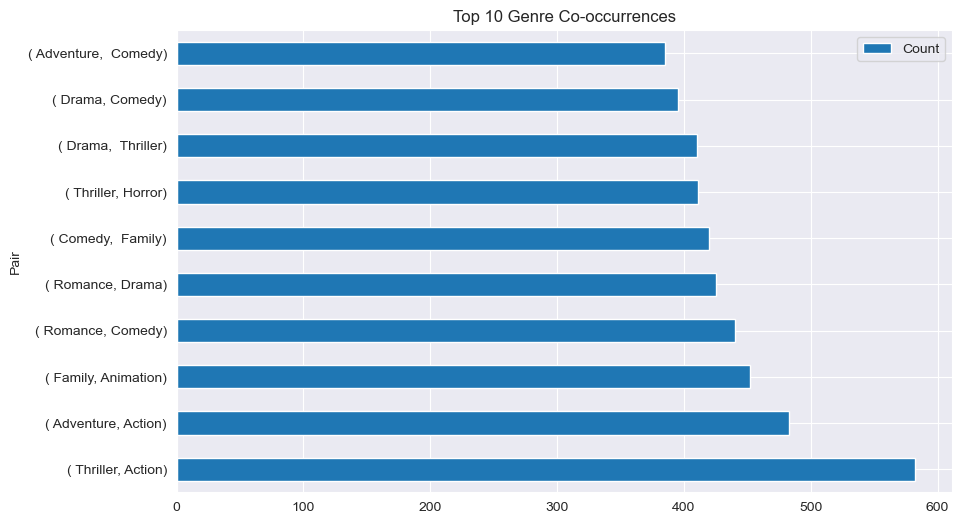

In [33]:
pair_df = pd.DataFrame(pair_counter.items(), columns=["Pair", "Count"])
pair_df = pair_df.sort_values("Count", ascending=False).head(10)

pair_df.plot(kind="barh", x="Pair", y="Count", figsize=(10,6))
plt.title("Top 10 Genre Co-occurrences")
plt.show()


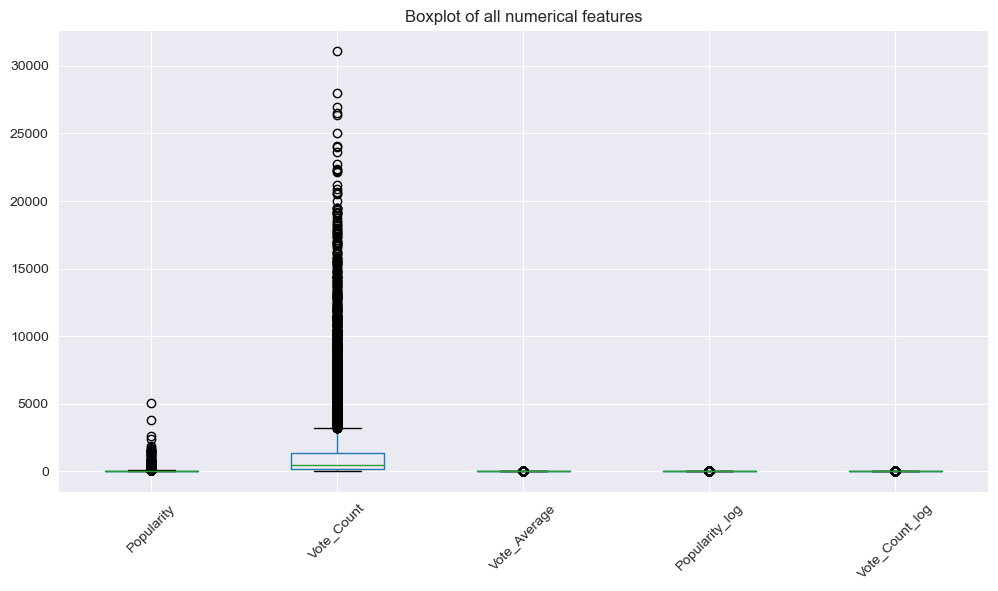

In [34]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12, 6))
df[numeric_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of all numerical features")
plt.show()

## Clustering

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.base import BaseEstimator, TransformerMixin

In [36]:
class GenreBinarizer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mlb = MultiLabelBinarizer()

    def fit(self, X, y=None):
        self.mlb.fit(X)
        return self

    def transform(self, X):
        return self.mlb.transform(X)

In [37]:
numeric_features = [
    'Vote_Average',
    'Popularity_log',
    'Vote_Count_log',
    'Year',
    'Month',
    'Day'
]

categorical_features = ['Original_Language']

text_feature = 'Overview'
genre_feature = 'genre_lists'

In [38]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

text_transformer = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=3000, stop_words='english'))
])

genre_transformer = Pipeline(steps=[
    ('bin', GenreBinarizer())
])

In [39]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('text', text_transformer, 'Overview'),
        ('genre', genre_transformer, 'genre_lists')
    ],
    remainder='drop'
)

In [40]:
svd = TruncatedSVD(n_components=150, random_state=42)

In [42]:
cluster_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('reduce_dim', svd),
    ('cluster', KMeans(
        n_clusters=6,
        init='k-means++',
        n_init=20,
        random_state=42
    ))
])

In [44]:
X_transformed = cluster_pipeline.named_steps['preprocess'].fit_transform(df)
X_reduced = cluster_pipeline.named_steps['reduce_dim'].fit_transform(X_transformed)

In [45]:
inertias = []
K_range = range(2, 15)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=20,
        random_state=42
    )
    kmeans.fit(X_reduced)
    inertias.append(kmeans.inertia_)

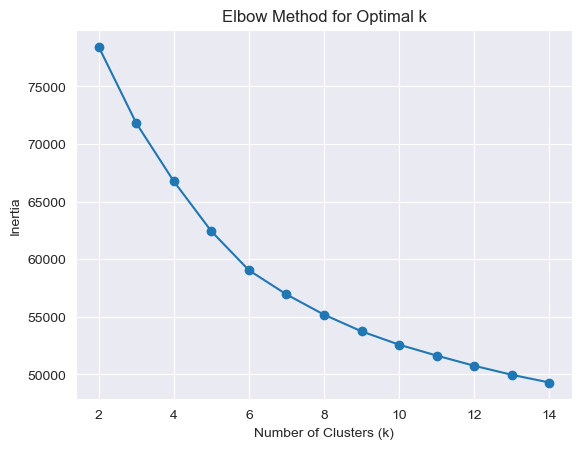

In [46]:
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [47]:
cluster_pipeline.fit(df)

,steps,"[('preprocess', ...), ('reduce_dim', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [48]:
df['Cluster'] = cluster_pipeline.named_steps['cluster'].labels_

In [49]:
df.groupby('Cluster')[['Popularity', 'Vote_Average', 'Vote_Count']].mean()

,Popularity,Vote_Average,Vote_Count
Cluster,,,
0,139.296056,6.898451,4594.390845
1,24.417298,6.409764,959.428694
2,39.751890,1.330058,4.219653
3,21.358428,7.026786,1132.291964
4,23.145233,6.313558,677.917770
5,23.154823,6.420919,859.438950


# Classification

In [51]:
df['Success'] = (df['Popularity'] > df['Popularity'].quantile(0.75)).astype(int)

In [52]:
df['Success'].value_counts(normalize=True)

Success
0    0.749949
1    0.250051
Name: proportion, dtype: float64

In [53]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer('all-mpnet-base-v2')

overview_embeddings = embedding_model.encode(df['Overview'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/308 [00:00<?, ?it/s]

In [54]:
overview_embeddings.shape

(9826, 768)

In [67]:
emb_df = pd.DataFrame( overview_embeddings, columns=[  f'emb_{i}' for i in range(overview_embeddings.shape[1]) ])

In [111]:
df['Genre_Count'] = df['genre_lists'].apply(len)

In [112]:
df['Quarter'] = pd.cut(
    df['Month'],
    bins=[0, 3, 6, 9, 12],
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

In [114]:
df['Era'] = pd.cut(
    df['Year'],
    bins=[1900, 2000, 2011, 2017, 2025],
    labels=[
        'Before_2000',
        '2000_2011',
        '2012_2017',
        '2018_Present'
    ]
)

In [116]:
df['Engagement_Score'] = (
    np.log1p(df['Vote_Count']) *
    df['Vote_Average']
)

In [178]:
structured = df[
    [
        'Vote_Count',
        'Vote_Average',
        'Year',
        'Month',
        'Day',
        'Original_Language',
        'Genre',
        'Era',
        'Genre_Count',
    ]
].reset_index(drop=True)

In [179]:
X = pd.concat([structured, emb_df], axis=1)
y = df['Success']

In [180]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [181]:
numeric_features = (
    ['Vote_Count',
     'Vote_Average',
     'Year',
     'Month',
     'Day',
     'Genre_Count']
    +
    list(emb_df.columns)
)

In [182]:
categorical_features = [
    'Original_Language',
    'Genre',
     'Era',
]

In [183]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ]
)

In [184]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [185]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score

In [186]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }

## XGBoost

In [187]:
# Class weightening
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos
scale_pos_weight

np.float64(3.0)

In [188]:
from xgboost import XGBClassifier

xgb_weighted = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

weighted_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb_weighted)
])

weighted_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Random forest

In [189]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf_balanced)
])

rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Logistic regression

In [190]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logreg_balanced =  LogisticRegression(
        max_iter=3000,
        class_weight='balanced'  # important for fairness
    )

logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', logreg_balanced) ])

logreg_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [191]:
results = []

results.append(
    evaluate_model("XGBoost Weighted", weighted_pipeline, X_test, y_test)
)

results.append(
    evaluate_model("Random Forest Balanced", rf_pipeline, X_test, y_test)
)
results.append(
    evaluate_model("Logistic regression", logreg_pipeline, X_test, y_test)
)


===== XGBoost Weighted =====
Accuracy: 0.8448626653102747
F1-score: 0.6482122260668973
ROC-AUC: 0.8494680146937155

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.94      0.90      1474
           1       0.75      0.57      0.65       492

    accuracy                           0.84      1966
   macro avg       0.81      0.75      0.77      1966
weighted avg       0.84      0.84      0.84      1966


===== Random Forest Balanced =====
Accuracy: 0.7527975584944049
F1-score: 0.028
ROC-AUC: 0.809453977341673

Classification Report:

              precision    recall  f1-score   support

           0       0.75      1.00      0.86      1474
           1       0.88      0.01      0.03       492

    accuracy                           0.75      1966
   macro avg       0.81      0.51      0.44      1966
weighted avg       0.78      0.75      0.65      1966


===== Logistic regression =====
Accuracy: 0.7477110885045778
F1-score: 

In [192]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="f1", ascending=False)

,model,accuracy,f1,roc_auc
0,XGBoost Weighted,0.844863,0.648212,0.849468
2,Logistic regression,0.747711,0.559503,0.811941
1,Random Forest Balanced,0.752798,0.028000,0.809454


In [193]:
best_model_name = results_df.sort_values(by="f1", ascending=False).iloc[0]["model"]
best_model_name

'XGBoost Weighted'

In [194]:
best_model = weighted_pipeline  

In [195]:
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.94      0.90      1474
           1       0.75      0.57      0.65       492

    accuracy                           0.84      1966
   macro avg       0.81      0.75      0.77      1966
weighted avg       0.84      0.84      0.84      1966



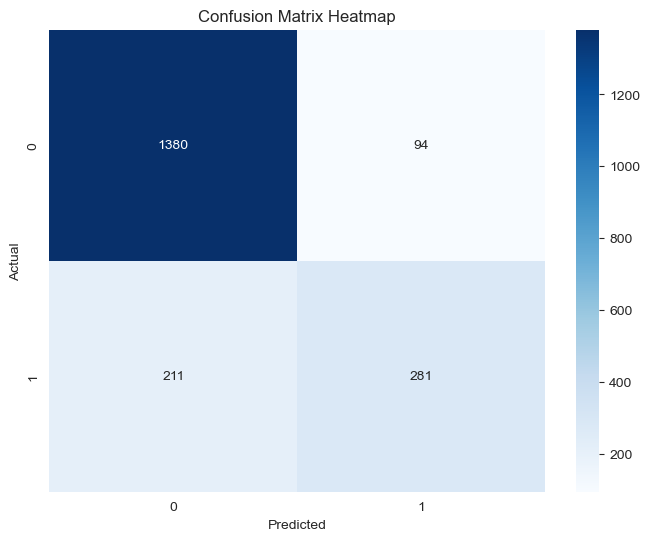

In [196]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm , annot=True, fmt="d", cmap="Blues" )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

- The model performs strongly on class 0 but struggles to correctly identify class 1, as shown by the lower recall.

- Class imbalance affects performance, causing the model to miss many positive cases despite reasonable precision.

- Overall accuracy appears high, but it hides the weaker detection of the minority class.

- Improving recall for class 1 should be a priority through resampling, threshold tuning, or alternative models.

## Classification with smote

In [197]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [198]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample( X_train_transformed, y_train)

In [199]:
from sklearn.linear_model import LogisticRegression

log_smote = LogisticRegression(
    max_iter=3000
)

log_smote.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [200]:
from sklearn.ensemble import RandomForestClassifier

rf_smote = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [201]:
from xgboost import XGBClassifier

xgb_smote = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb_smote.fit(X_train_smote, y_train_smote)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [202]:
y_pred_log = log_smote.predict(X_test_transformed)
y_pred_rf = rf_smote.predict(X_test_transformed)
y_pred_xgb = xgb_smote.predict(X_test_transformed)

In [214]:
y_proba_xgb = xgb_smote.predict_proba(X_test_transformed)[:, 1]
y_proba_rf = rf_smote.predict_proba(X_test_transformed)[:, 1]
y_proba_log = log_smote.predict_proba(X_test_transformed)[:, 1]

In [203]:
print("LOGISTIC + SMOTE")
print(classification_report(y_test, y_pred_log))

print()
print("RF + SMOTE")
print(classification_report(y_test, y_pred_rf))

print()
print("XGB + SMOTE")
print(classification_report(y_test, y_pred_xgb))

LOGISTIC + SMOTE
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1474
           1       0.51      0.61      0.56       492

    accuracy                           0.75      1966
   macro avg       0.68      0.71      0.69      1966
weighted avg       0.77      0.75      0.76      1966


RF + SMOTE
              precision    recall  f1-score   support

           0       0.80      0.97      0.88      1474
           1       0.76      0.26      0.39       492

    accuracy                           0.80      1966
   macro avg       0.78      0.62      0.63      1966
weighted avg       0.79      0.80      0.76      1966


XGB + SMOTE
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      1474
           1       0.78      0.55      0.64       492

    accuracy                           0.85      1966
   macro avg       0.82      0.75      0.77      1966
weighted avg       0.84      0.8

In [215]:
results_smote = []

results_smote.append({
    "model": "LogReg + SMOTE",
    "accuracy": accuracy_score(y_test, y_pred_log),
    "f1": f1_score(y_test, y_pred_log),
    "roc_auc": roc_auc_score(y_test, y_proba_log)
})

results_smote.append({
    "model": "RF + SMOTE",
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "f1": f1_score(y_test, y_pred_rf),
    "roc_auc": roc_auc_score(y_test, y_proba_rf)
})

results_smote.append({
    "model": "XGB + SMOTE",
    "accuracy": accuracy_score(y_test, y_pred_xgb),
    "f1": f1_score(y_test, y_pred_xgb),
     "roc_auc": roc_auc_score(y_test, y_proba_xgb)
})

pd.DataFrame(results_smote).sort_values(by="f1", ascending=False)

,model,accuracy,f1,roc_auc
2,XGB + SMOTE,0.848423,0.643541,0.863002
0,LogReg + SMOTE,0.754323,0.555658,0.804788
1,RF + SMOTE,0.795015,0.392157,0.823529


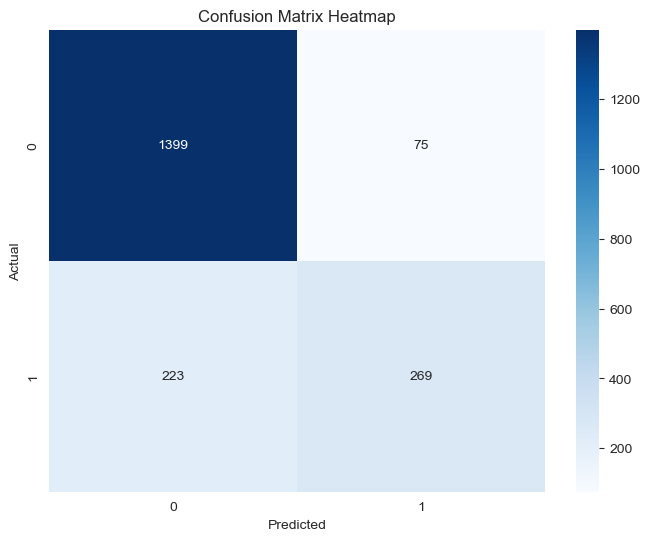

In [216]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8,6))
sns.heatmap(cm , annot=True, fmt="d", cmap="Blues" )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

📊 Movie Success Prediction – Dataset Overview & Modeling Report
📁 Dataset Overview

The dataset contains:

9,837 entries
9 columns
No duplicate records
Missing values present in almost all columns, which were removed during preprocessing

The dataset spans movie releases from the early 1900s to 2020, with a strong concentration in recent decades (2000–2020), reflecting the rapid growth of modern film production.

🔎 Exploratory Data Analysis (EDA)
📈 Movie production over time

Movie production is very low in early decades and increases sharply after the 2000s. The majority of films are concentrated in the 2000–2020 period, reflecting the expansion of the global film industry and digital distribution platforms.

📅 Monthly release patterns

October and September show the highest number of movie releases. However, there is no consistent seasonal trend across months, indicating that movie releases are irregularly distributed throughout the year rather than following a strict seasonal pattern.

🎯 Popularity distribution

Popularity is highly right-skewed:

Most movies have low popularity values
A small number of movies achieve extremely high popularity

This indicates a strong imbalance where only a few films dominate audience attention.

🗳️ Vote analysis
Vote count distribution is highly skewed
After log transformation, the distribution becomes more balanced but remains slightly left-skewed (skewness ≈ -0.59)
Most movies cluster around moderate vote counts
Around 100 movies have zero votes, representing an important edge case
⭐ Vote average distribution
Slight left skew observed
Most ratings fall between 6 and 7
Few movies receive very low ratings
🌍 Language distribution
English dominates the dataset (77%)
Japanese (~6.5%) follows
Spanish, French, and Korean each contribute a small share (~1–3.5%)

This shows a strong bias toward English-language productions.

🎬 Genre distribution
Drama (14.5%) – most common
Comedy (11.75%)
Action (10.41%)
Thriller (9.65%)
Adventure (7.18%)

The dataset is dominated by mainstream narrative-driven genres.

🤖 Modeling Approach

Three models were tested for predicting movie success:

Logistic Regression
Random Forest
XGBoost

Due to class imbalance in the target variable, additional strategies were applied:

Class weighting
SMOTE oversampling

The best performing model was XGBoost with class weighting, which achieved the strongest balance between precision and recall.

🧪 Feature Engineering Experiments

To improve predictive performance, several feature engineering strategies were evaluated.

Genre_Count → number of genres associated with each movie

Motivation:
Movies with multiple genres may reflect broader audience appeal and higher production scale.

📆 Temporal Feature Engineering (Era Grouping)

Release years were grouped into four eras:
    
Before 2000
2000–2011
2012–2017
2018–Present

Motivation:
To capture structural changes in the film industry over time and shifting audience preferences.


🧠 Key Insights from Feature Engineering

Although both features were theoretically meaningful, neither improved predictive performance. This suggests that:

The predictive signal is already well captured by existing features 
Engineered features introduced redundancy rather than new information
The dataset has a limited feature ceiling for classical tabular modeling
📊 Final Model Performance

The final selected model was XGBoost with class weighting, achieving:

Accuracy: ~0.845
F1-score: ~0.648
ROC-AUC: ~0.849

This model provided the best overall balance between precision and recall.

🏁 Conclusion

Feature engineering experiments, including genre complexity and temporal grouping, did not lead to significant improvements in predictive performance. This suggests that the engineered features did not provide additional useful information beyond the original dataset representation.

As a result, the XGBoost model with class weighting was selected as the final model due to its best overall balance between F1-score and accuracy.